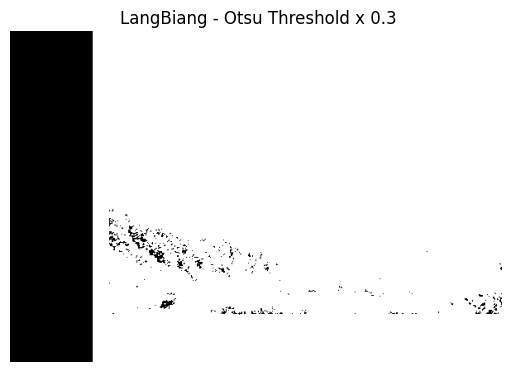

In [ ]:
#cau1
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu

img = Image.open('exercise/dalat.jpg').convert('L')

region = np.array(img)[0:400, 0:600]

shifted = np.zeros_like(region)
shifted[:, 100:] = region[:, :-100]

thres = threshold_otsu(shifted)

binary = shifted > (thres * 0.3)

result = Image.fromarray((binary * 255).astype(np.uint8))
result.save('lang_biang.jpg')

plt.imshow(result, cmap='gray')
plt.title('LangBiang - Otsu Threshold x 0.3')
plt.axis('off')
plt.show()


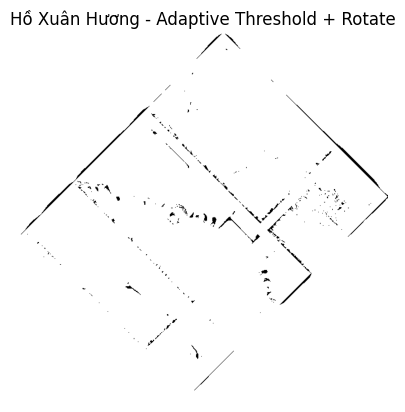

In [ ]:
#cau2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as nd
from skimage.filters import threshold_local


img = Image.open('exercise/dalat.jpg').convert('L')

roi = np.array(img)[400:800, 200:700]

rotated = nd.rotate(roi, 45, reshape=True)

thres = threshold_local(rotated, 35, offset=60)
binary = rotated > thres

result = Image.fromarray((binary * 255).astype(np.uint8))
result.save('ho_xuan_huong.jpg')

plt.imshow(result, cmap='gray')
plt.title('Hồ Xuân Hương - Adaptive Threshold + Rotate')
plt.axis('off')
plt.show()


Đã lưu ảnh: quan_truong_lam_vien.jpg


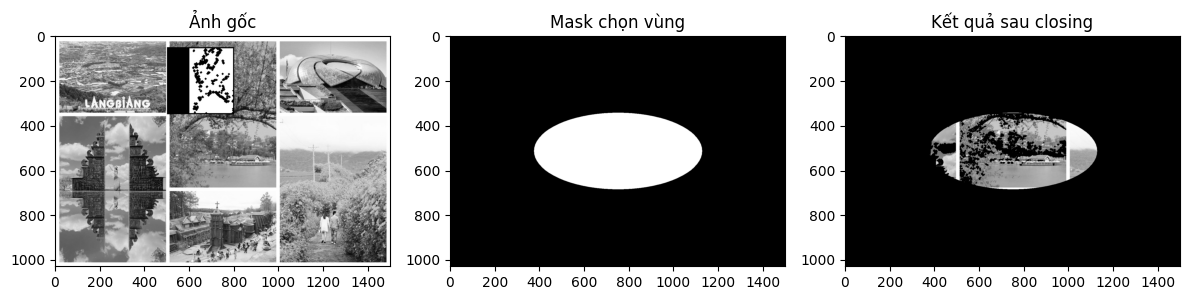

In [ ]:
#cau3
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import binary_closing
import os

# Đường dẫn tới ảnh (đổi lại nếu bạn chạy trên máy)
image_path = 'quan_truong_lam_vien.jpg'

# Kiểm tra ảnh có tồn tại không
if not os.path.exists(image_path):
    print("Không tìm thấy ảnh tại:", image_path)
else:
    # Đọc ảnh gốc và chuyển sang ảnh xám
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Nhị phân hóa ảnh xám
    _, binary = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

    # Tạo mask chọn vùng Quảng trường Lâm Viên (ví dụ hình ellipse giữa ảnh)
    mask = np.zeros_like(binary)
    height, width = binary.shape
    center_coordinates = (width // 2, height // 2)
    axes_lengths = (width // 4, height // 6)
    cv2.ellipse(mask, center=center_coordinates, axes=axes_lengths,
                angle=0, startAngle=0, endAngle=360, color=255, thickness=-1)

    # Áp dụng mask để chọn vùng quan tâm
    selected = cv2.bitwise_and(binary, binary, mask=mask)

    # Áp dụng phép closing để làm mịn vùng chọn
    structure = np.array([[0,1,0],
                          [1,1,1],
                          [0,1,0]], dtype=bool)
    closed = binary_closing(selected, structure=structure, iterations=3).astype(np.uint8) * 255

    # Áp dụng lên ảnh gốc
    result = cv2.bitwise_and(image, image, mask=closed)

    # Lưu kết quả
    output_path = 'quan_truong_lam_vien.jpg'
    cv2.imwrite(output_path, result)
    print("Đã lưu ảnh:", output_path)

    # Hiển thị ảnh
    plt.figure(figsize=(12,4))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Ảnh gốc")

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask chọn vùng")

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title("Kết quả sau closing")
    plt.tight_layout()
    plt.show()



==== MENU ====
1. geometric_transformation
   a. Rotate
   b. Scale
   c. Shift
2. segment
   d. Adaptive thresholding
   e. Binary dilation
   f. Binary erosion
   g. Otsu


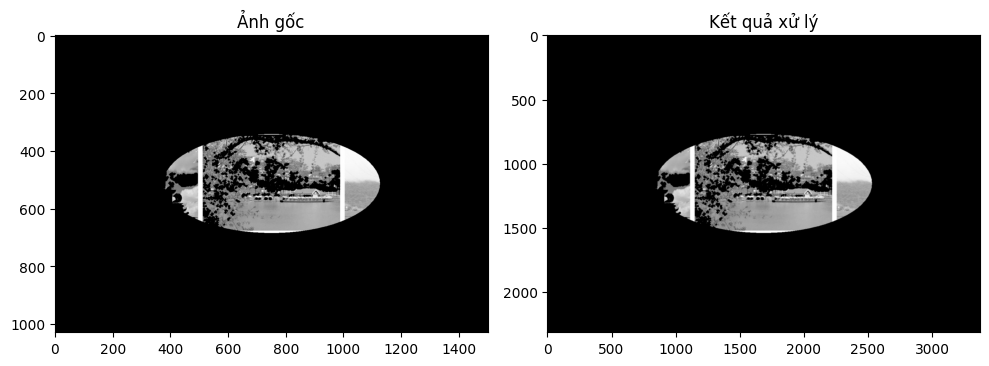

In [ ]:
#cau4
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os

# ======= Hàm xử lý =======
def rotate(image, angle=45):
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    return cv2.warpAffine(image, M, (w, h))

def scale(image, fx=1.5, fy=1.5):
    return cv2.resize(image, None, fx=fx, fy=fy, interpolation=cv2.INTER_LINEAR)

def shift(image, dx=50, dy=30):
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    h, w = image.shape[:2]
    return cv2.warpAffine(image, M, (w, h))

def adaptive_threshold(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                 cv2.THRESH_BINARY, 11, 2)

def binary_dilation(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    kernel = np.ones((5, 5), np.uint8)
    return cv2.dilate(binary, kernel, iterations=1)

def binary_erosion(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    kernel = np.ones((5, 5), np.uint8)
    return cv2.erode(binary, kernel, iterations=1)

def otsu_threshold(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, result = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return result

def apply_option(image, choice):
    if choice == 'a':
        return rotate(image)
    elif choice == 'b':
        return scale(image)
    elif choice == 'c':
        return shift(image)
    elif choice == 'd':
        return adaptive_threshold(image)
    elif choice == 'e':
        return binary_dilation(image)
    elif choice == 'f':
        return binary_erosion(image)
    elif choice == 'g':
        return otsu_threshold(image)
    else:
        print("⚠️ Lựa chọn không hợp lệ:", choice)
        return image

# ======= Chạy chương trình =======

# Đường dẫn ảnh
image_path = 'quan_truong_lam_vien.jpg'  # Đổi lại nếu bạn lưu chỗ khác

# Kiểm tra ảnh có tồn tại không
if not os.path.exists(image_path):
    print("❌ Không tìm thấy ảnh tại:", image_path)
    exit()

# Đọc ảnh
image = cv2.imread(image_path)
if image is None:
    print("❌ Lỗi khi đọc ảnh. Kiểm tra đường dẫn và định dạng.")
    exit()

# In menu
print("\n==== MENU ====")
print("1. geometric_transformation")
print("   a. Rotate")
print("   b. Scale")
print("   c. Shift")
print("2. segment")
print("   d. Adaptive thresholding")
print("   e. Binary dilation")
print("   f. Binary erosion")
print("   g. Otsu")

# Nhập lựa chọn
choice1 = input("\nNhập lựa chọn 1 (a-g): ").strip().lower()
choice2 = input("Nhập lựa chọn 2 nếu muốn kết hợp (bỏ trống nếu không): ").strip().lower()

# Áp dụng lựa chọn
output = apply_option(image, choice1)
if choice2:
    output = apply_option(output, choice2)

# Hiển thị kết quả
plt.figure(figsize=(10,4))
plt.subplot(1,2,1), plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)), plt.title("Ảnh gốc")
if len(output.shape) == 2:
    plt.subplot(1,2,2), plt.imshow(output, cmap='gray'), plt.title("Kết quả xử lý")
else:
    plt.subplot(1,2,2), plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)), plt.title("Kết quả xử lý")
plt.tight_layout()
plt.show()
